# Tugas 1 Machine Learning

Muhammad Hidayat

# 1. Pendahuluan

``` yaml
Nama: Muhammad Hidayat
NIM: 052747132
```

Tujuan dari tugas ini adalah untuk mempersiapkan dataset yang akan
digunakan dalam proses pemodelan machine learning. Dataset yang
digunakan memiliki beberapa permasalahan umum, seperti data yang hilang
dan inkonsistensi format data, sehingga memerlukan langkah-langkah
preprocessing untuk memastikan kualitas data sebelum digunakan dalam
model.

# 2. Persiapan Lingkungan

## 2.1 Library yang digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Penjelasan mengenai library yang digunakan:

- `numpy`: digunakan untuk operasi matematika dan manipulasi array
- `pandas`: digunakan untuk manipulasi dan analisis data, fondasi untuk
  DataFrame
- `matplotlib.pyplot`: digunakan untuk membuat visualisasi data
- `sklearn.impute.SimpleImputer`: digunakan untuk mengisi data yang
  hilang
- `sklearn.compose.ColumnTransformer`: digunakan untuk menggabungkan
  transformasi kolom
- `sklearn.preprocessing.OneHotEncoder`: digunakan untuk mengonversi
  data kategorikal menjadi numerik
- `sklearn.preprocessing.StandardScaler`: digunakan untuk melakukan
  normalisasi data
- `sklearn.model_selection.train_test_split`: digunakan untuk membagi
  data menjadi data latih dan data uji
- `sklearn.linear_model.LinearRegression`: digunakan untuk pemodelan
  regresi linear

## 2.2 Dataset

Dataset yang digunakan,
[dataset_tugas1_preprocessing.csv](./dataset_tugas1_preprocessing.csv),
berisi informasi mahasiswa dari berbagai program studi. Dataset ini
sengaja dirancang dengan beberapa permasalahan umum dalam dunia nyata,
seperti data yang hilang (missing values), inkonsistensi format data,
serta tipe data kategorikal yang belum siap diproses oleh model machine
learning.

Langkah pertama dalam eksplorasi data adalah memuat dataset ke dalam
DataFrame menggunakan pandas.

In [2]:
# Memuat dataset
data = pd.read_csv('dataset_tugas1_preprocessing.csv')

# Menampilkan beberapa baris pertama dari dataset
display(data.head())

# 3. Eksplorasi Data

Sebelum melakukan pemodelan, penting untuk memahami struktur dan
kualitas data yang kita miliki. Salah satu langkah awal adalah
mengetahui struktur dataset, termasuk jumlah baris dan kolom, serta tipe
data dari setiap kolom.

Dari <a href="#tbl-data-head" class="quarto-xref">Tabel 1</a>, terdapat
99 baris data, tiapa baris mewakili satu mahasiswa, dan terdapat 8 kolom
yang memberikan informasi tentang mahasiswa tersebut. Berikut adalah
penjelasan singkat mengenai setiap kolom:

- **ID**: Merupakan identifier unik untuk setiap mahasiswa. Ini biasanya
  digunakan oleh Nomor Induk Mahasiswa (NIM). Dalam hal ini, ID berupa
  format `MHXXX` dimana `XXX` adalah angka yang menunjukkan urutan
  mahasiswa.
- **Nama**: Merupakan nama lengkap mahasiswa. Ini digunakan sebagai
  pelengkap dalam identifikasi mahasiswa.
- **Jenis_Kelamin**: Merupakan jenis kelamin mahasiswa, yang dapat
  berupa ‘Laki-laki’ atau ‘Perempuan’.
- **Prodi**: Merupakan program studi yang diikuti oleh mahasiswa,
  seperti ‘Informatika’, ‘Teknik Komputer’, ‘Data Science’, dll.
- **Status**: Merupakan status mahasiswa, yang dapat berupa ‘Aktif’,
  ‘Cuti’, ‘Lulus’, atau ‘DO’ atau “*dropout*”.
- **Nilai_Akhir**: Merupakan nilai akhir mahasiswa dalam bentuk mutu
  huruf, seperti ‘A’, ‘B’, ‘C’, ‘D’, atau ‘E’. Nilai ini menunjukkan
  performa akademik mahasiswa, dengan ‘A’ sebagai performa terbaik dan
  ‘E’ sebagai performa terburuk.
- **Tanggal_Ujian**: Merupakan tanggal ujian yang diikuti oleh
  mahasiswa. Terdapat dua format, yaittu ‘YYYY/MM/DD’ dan ‘DD-MM-YYYY’.
  Dalam pemodelan, kita perlu memastikan bahwa format tanggal konsisten
  agar dapat diproses dengan benar.
- **Umur**: Merupakan umur mahasiswa dalam tahun.

In [3]:
# Menampilkan informasi tentang dataset
display(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     str    
 1   Nama           99 non-null     str    
 2   Jenis_Kelamin  99 non-null     str    
 3   Prodi          99 non-null     str    
 4   Status         99 non-null     str    
 5   Nilai_Akhir    70 non-null     str    
 6   Tanggal_Ujian  99 non-null     str    
 7   Umur           90 non-null     float64
dtypes: float64(1), str(7)
memory usage: 6.3 KB

None

Menggunakan `data.info()`, kita dapat melihat bahwa sebagian besar kolom
masih berupa tipe `str` atau teks, termasuk ‘Tanggal_Ujian’. Data ini
akan diolah menjadi tipe data yang sesuai untuk pemodelan.

In [4]:
# Analisis statistik deskriptif untuk kolom numerik
numeric_summary = data.describe()
display(numeric_summary)

# Hitung jumlah entri string unik per kolom
unique_entries = data.apply(lambda col: col.nunique())

# Cetak hasilnya
print("Jumlah entri string unik per kolom:")
display(unique_entries)

Jumlah entri string unik per kolom:

ID               99
Nama             10
Jenis_Kelamin     2
Prodi             4
Status            4
Nilai_Akhir       5
Tanggal_Ujian    97
Umur             13
dtype: int64

In [5]:
# Tampilkan entri string unik untuk setiap kolom
for column in data.columns:
    unique_entries = data[column].unique()
    if len(unique_entries) <= 10:  # Hanya tampilkan jika jumlah entri unik tidak terlalu banyak
        print(f"Unique string entries for column '{column}':\n{unique_entries}\n")

Unique string entries for column 'Nama':
<StringArray>
['Iwan', 'Eka', 'Joko', 'Gita', 'Adi', 'Hana', 'Dina', 'Budi', 'Citra',
 'Farhan']
Length: 10, dtype: str

Unique string entries for column 'Jenis_Kelamin':
<StringArray>
['Laki-laki', 'Perempuan']
Length: 2, dtype: str

Unique string entries for column 'Prodi':
<StringArray>
['Teknik Komputer', 'Data Science', 'Informatika', 'Sistem Informasi']
Length: 4, dtype: str

Unique string entries for column 'Status':
<StringArray>
['Aktif', 'Lulus', 'DO', 'Cuti']
Length: 4, dtype: str

Unique string entries for column 'Nilai_Akhir':
<StringArray>
[nan, 'E', 'D', 'C', 'B', 'A']
Length: 6, dtype: str


Terdapat 2 jenis kelamin, 4 program studi, 4 status mahasiswa, dan 5
nilai akhir yang berbeda. Hal ini menunjukkan perlu dilakukan encoding
pada kolom-kolom tersebut agar dapat digunakan dalam model machine
learning. Untuk nama, meskipun hanya terdapat 10 entri unik, ini hanya
tanda identifikasi mahasiswa, sehingga tidak akan digunakan dalam
pemodelan dan tidak perlu diencoding.

Berikut banyak baris per entri unik untuk jenis kelamin, prodi, status,
dan nilai akhir.

In [6]:
# Hitung banyak baris per entri unik
# Hanya untuk jenis kelamin, prodi, status, dan nilai akhir
columns = ['Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']

for column in columns:
    unique_counts = data[column].value_counts()
    print(f"Unique counts for column '{column}':\n{unique_counts}\nTotal: {unique_counts.sum()}\n")

Unique counts for column 'Jenis_Kelamin':
Jenis_Kelamin
Laki-laki    50
Perempuan    49
Name: count, dtype: int64
Total: 99

Unique counts for column 'Prodi':
Prodi
Teknik Komputer     28
Informatika         28
Sistem Informasi    23
Data Science        20
Name: count, dtype: int64
Total: 99

Unique counts for column 'Status':
Status
Cuti     29
DO       26
Aktif    25
Lulus    19
Name: count, dtype: int64
Total: 99

Unique counts for column 'Nilai_Akhir':
Nilai_Akhir
C    17
D    16
A    16
B    12
E     9
Name: count, dtype: int64
Total: 70


Selain itu, dari lima kolom pertama yang ditampilkan, terdapat beberapa
nilai yang hilang (NaN) pada kolom ‘Nilai_Akhir’ dan ‘Umur’. Untuk
mengetahui jumlah nilai yang hilang pada setiap kolom, kita dapat
menggunakan fungsi `isnull()` dan `sum()`. Dan untuk melihat baris mana
saja yang memiliki nilai yang hilang, kita dapat menggunakan fungsi
`isnull()` dengan `any(axis=1)` untuk memfilter baris yang memiliki
setidaknya satu nilai yang hilang.

In [7]:
# Filter baris dengan nilai NA
na_rows = data[data.isnull().any(axis=1)]

# Hitung jumlah total nilai NA
total_cols_na = data.isnull().sum()
# Hitung baris dengan nilai NA
total_rows_na = na_rows.shape[0]

total_na = data.isnull().sum().sum()

# Cetak jumlah nilai NA per kolom
print("Count of NA values per column:")
print(total_cols_na[total_cols_na > 0])

# Cetak baris dengan nilai NA
print("Rows with NA values:")
display(na_rows.tail())

# Cetak jumlah total baris dengan nilai NA
print(f"Total count of rows with NA values: {total_rows_na}")

# Cetak jumlah total nilai NA
print(f"Total count of NA values: {total_na}")

Count of NA values per column:
Nilai_Akhir    29
Umur            9
dtype: int64
Rows with NA values:

Total count of rows with NA values: 35
Total count of NA values: 38

Di sini terdapat 29 nilai kosong pada ‘Nilai_Akhir’ dan 9 nilai kosong
pada ‘Umur’. Hal ini menunjukkan bahwa kita perlu melakukan penanganan
terhadap data yang hilang sebelum melanjutkan ke tahap pemodelan.

# 4. Preprocessing Data

Di sini, kita akan melakukan beberapa langkah preprocessing untuk
menangani permasalahan yang ada dalam dataset, seperti data yang hilang,
inkonsistensi format tanggal, dan encoding data kategorikal. Data yang
diproses ini akan ditaruh dalam variabel `data_preprocessed` untuk
digunakan dalam tahap pemodelan selanjutnya.

Pertama, kita akan membuat dataframe baru dan menyalin semua data dari
data aslinya. Kolom ‘ID’ dipertahankan, karena kolom ini bertindak
sebagai identifikasi dan tidak akan digunakan dalam pemodelan.
Kolom-kolom lainnya akan diproses seperlunya. Dan untuk kolom ‘Nama’,
ini akan dihapus karena kolom ini hanya sebagai pelengkap dan tidak akan
digunakan dalam pemodelan.

In [8]:
# Membuat dataframe baru untuk data yang sudah diproses
data_preprocessed = data.copy()

# Menghapus kolom 'Nama' karena tidak akan digunakan dalam pemodelan
data_preprocessed.drop(columns=['Nama'], inplace=True)

## 4.1 Penanganan Data yang Hilang

Sebelumnya dalam <a href="#sec-eda" class="quarto-xref">Bagian 3</a>,
kita sudah mengetahui bahwa terdapat nilai yang hilang pada kolom
‘Nilai_Akhir’ dan ‘Umur’. Untuk menangani data yang hilang, metode
berikut akan digunakan:

- ‘Nilai_Akhir’: Nilai adalah data yang kritis. Melakukan pengisian
  nilai akan mengganggu integritas data, sehingga 29 baris dengan nilai
  yang hilang pada kolom ini akan dihapus.
- ‘Umur’: Data umur tidak terlalu kritis dan bisa diperkirakan
  berdasarkan data yang ada. Nilai yang hilang pada kolom ini akan diisi
  dengan nilai rata-rata umur dari data yang tersedia. Metode yang
  digunakan adalah `SimpleImputer` dari library `sklearn`, dengan
  strategi ‘mean’ untuk mengisi nilai yang hilang dengan rata-rata.

In [9]:
# Untuk kolom 'Nilai_Akhir', nilai yang hilang akan dihapus
data_preprocessed = data_preprocessed.dropna(subset=['Nilai_Akhir'])

# Untuk kolom 'Umur', nilai yang hilang akan diisi dengan nilai rata-rata umur
imputer = SimpleImputer(strategy='mean')
data_preprocessed['Umur'] = imputer.fit_transform(data_preprocessed[['Umur']])

## 4.2 Standarisasi Format Tanggal

Kolom ‘Tanggal_Ujian’ memiliki dua format tanggal yang berbeda, yaitu
‘YYYY/MM/DD’ dan ‘DD-MM-YYYY’. Untuk memastikan konsistensi dalam
pemrosesan data, kita akan mengubah semua format tanggal menjadi format
yang sama sekaligus membuat kolom menjadi tipe data datetime.

Kita akan menggunakan fungsi `pd.to_datetime()` dari pandas untuk
melakukan konversi ini. Dikarenakan terdapat dua format tanggal yang
berbeda, kita akan menggunakan parameter `format='mixed'` untuk
memungkinkan pandas mengenali kedua format tersebut. Selain itu, kita
juga akan menggunakan parameter `yearfirst=True` dan `dayfirst=True`
untuk memastikan bahwa pandas dapat mengidentifikasi bagian tahun dan
hari dengan benar.

In [10]:
# Mengubah format tanggal menjadi format yang sama dan mengonversi ke tipe datetime
data_preprocessed['Tanggal_Ujian'] = pd.to_datetime(data_preprocessed['Tanggal_Ujian'], errors='raise', format='mixed', yearfirst=True, dayfirst=True)

## 4.3 Encoding Data Kategorikal

Encoding data kategorikal diperlukan agar data tersebut dapat digunakan
dalam model machine learning, yang umumnya hanya dapat memproses data
numerik. Berikut adalah beberapa asumsi terkait kolom-kolom kategorikal
dalam dataset ini beserta metode encoding yang akan digunakan:

- **Jenis_Kelamin**: Terdapat dua kategori, yaitu ‘Laki-laki’ dan
  ‘Perempuan’. Kita akan menggunakan encoding manual dengan memberikan
  nilai 0 untuk ‘Laki-laki’ dan 1 untuk ‘Perempuan’.
- **Nilai_Akhir**: Terdapat lima kategori, yaitu ‘A’, ‘B’, ‘C’, ‘D’, dan
  ‘E’. Data ini bersifat ordinal dan memiliki urutan mutu, sehingga kita
  akan menggunakan encoding manual berbobot dengan memberikan nilai 4
  untuk ‘A’, 3 untuk ‘B’, 2 untuk ‘C’, 1 untuk ‘D’, dan 0 untuk ‘E’.
- **Status**: Terdapat empat kategori, yaitu ‘Aktif’, ‘Cuti’, ‘Lulus’,
  dan ‘DO’. Untuk mempermudah proses encoding, kita akan menggunakan
  *one-hot encoding*, yang akan menghasilkan empat kolom baru,
  masing-masing untuk setiap kategori status, dengan nilai 1 jika
  mahasiswa memiliki status tersebut dan 0 jika tidak.
- **Prodi**: Terdapat empat kategori, yaitu ‘Informatika’, ‘Teknik
  Komputer’, ‘Data Science’, dan ‘Sistem Informasi’. Sama seperti
  ‘Status’, kita akan menggunakan *one-hot encoding* untuk kolom ini.

In [11]:
# Kategori untuk jenis kelamin (manual)
gender_categories = {'Laki-laki': 0, 'Perempuan': 1}

# Kategori untuk nilai akhir (manual, berbobot)
grade_categories = {'A': 4, 'B': 3, 'C': 2, 'D': 1, 'E': 0}

Untuk encoding manual, operasi `map` sederhana akan digunakan. Sedangkan
untuk melakukan *one-hot encoding*, kita akan menggunakan fungsi
`get_dummies` dari pandas. Alternatif lain untuk melakukan *one-hot
encoding* adalah dengan menggunakan `ColumnTransformer` dan
`OneHotEncoder` dari library `sklearn`, namun prosesnya lebih kompleks,
sehingga tidak akan digunakan di sini.

In [12]:
# menggunakan pd.get_dummies() untuk melakukan one-hot encoding pada kolom 'Status' dan 'Prodi'
# fungsi ini juga membuat salinan data baru, sehingga kita bisa melakukan encoding manual pada kolom 'Jenis_Kelamin' dan 'Nilai_Akhir' tanpa mempengaruhi data asli
data_preprocessed_3 = pd.get_dummies(data_preprocessed, columns=['Status', 'Prodi'], prefix=['Status', 'Prodi'], drop_first=False, dtype=int)

# Melakukan encoding manual untuk kolom 'Jenis_Kelamin' dan 'Nilai_Akhir'
data_preprocessed_3['Jenis_Kelamin'] = data_preprocessed['Jenis_Kelamin'].map(gender_categories)
data_preprocessed_3['Nilai_Akhir'] = data_preprocessed['Nilai_Akhir'].map(grade_categories)

display(data_preprocessed_3[['ID', 'Jenis_Kelamin', 'Nilai_Akhir', 'Tanggal_Ujian', 'Umur', 'Status_Aktif', 'Prodi_Teknik Komputer']].head())

In [14]:
display(data_preprocessed_3.info())
display(data_preprocessed_3.describe())

<class 'pandas.DataFrame'>
Index: 70 entries, 1 to 97
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      70 non-null     str           
 1   Jenis_Kelamin           70 non-null     int64         
 2   Nilai_Akhir             70 non-null     int64         
 3   Tanggal_Ujian           70 non-null     datetime64[us]
 4   Umur                    70 non-null     float64       
 5   Status_Aktif            70 non-null     int64         
 6   Status_Cuti             70 non-null     int64         
 7   Status_DO               70 non-null     int64         
 8   Status_Lulus            70 non-null     int64         
 9   Prodi_Data Science      70 non-null     int64         
 10  Prodi_Informatika       70 non-null     int64         
 11  Prodi_Sistem Informasi  70 non-null     int64         
 12  Prodi_Teknik Komputer   70 non-null     int64         
dtypes: datet

None

# 5. Pemodelan Machine Learning

Selanjutnya, kita akan melakukan pemodelan machine learning. Untuk
pemodelan ini, kita akan menggunakan regresi linear untuk melakukan
prediksi nilai akhir mahasiswa.

Sebelum melakukan pemodelan, data perlu dinormalisasi. Karena akan
menggunakan regresi linear, maka metode normalisasi yang digunakan
adalah *standarisasi* berdasarkan mean dan standar deviasi.

Karena “Tanggal_Ujian” masih dalam bentuk datetime, perlu diubah menjadi
bentuk numerik terlebih dahulu.

Untuk melakukan normalisasi, kita akan menggunakan fungsi
`StandardScaler` dari library `sklearn`:

In [15]:
# Membuat objek StandardScaler
scaler = StandardScaler()

# Membuat salinan tabel data
data_premodel = data_preprocessed_3.copy().drop('ID', axis=1)

# Mengubah 'Tanggal_Ujian' menjadi bentuk numerik
data_premodel['Tanggal_Ujian'] = pd.to_numeric(data_premodel['Tanggal_Ujian'])

# Melakukan standarisasi pada data
data_premodel_scaled = scaler.fit_transform(data_premodel)
data_premodel_scaled_df = pd.DataFrame(data_premodel_scaled, columns=data_premodel.columns)

In [16]:
display(data_premodel_scaled_df.head())
display(data_premodel_scaled_df.info())
display(data_premodel_scaled_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Jenis_Kelamin           70 non-null     float64
 1   Nilai_Akhir             70 non-null     float64
 2   Tanggal_Ujian           70 non-null     float64
 3   Umur                    70 non-null     float64
 4   Status_Aktif            70 non-null     float64
 5   Status_Cuti             70 non-null     float64
 6   Status_DO               70 non-null     float64
 7   Status_Lulus            70 non-null     float64
 8   Prodi_Data Science      70 non-null     float64
 9   Prodi_Informatika       70 non-null     float64
 10  Prodi_Sistem Informasi  70 non-null     float64
 11  Prodi_Teknik Komputer   70 non-null     float64
dtypes: float64(12)
memory usage: 6.7 KB

None

Langkah selanjutnya adalah membagi data menjadi data latih dan data uji.
Data latih digunakan untuk melatih model, sedangkan data uji digunakan
untuk menguji performa model yang telah dibuat. Dari soal, diminta untuk
membagi data menjadi 80% untuk data latih dan 20% untuk data uji. Untuk
membagi data, kita akan menggunakan fungsi `train_test_split` dari
library `sklearn`. Untuk nilai y, kita akan menggunakan kolom
‘Nilai_Akhir’ sebagai target. Sedangkan untuk nilai X, kita akan
menggunakan semua kolom selain ‘Nilai_Akhir’ sebagai fitur.

In [17]:
X = data_premodel_scaled_df.drop('Nilai_Akhir', axis=1)
y = data_premodel_scaled_df['Nilai_Akhir']

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan jumlah data latih dan data uji
print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))

Jumlah data latih: 56
Jumlah data uji: 14

Setelah melakukan normalisasi dan membagi data menjadi data latih dan
data uji, kita akan melakukan pemodelan menggunakan regresi linear
dengan fungsi `LinearRegression` dari library `sklearn`.

In [18]:
# Membuat objek regresi linear
regressor = LinearRegression()

# Melatih model menggunakan data latih
regressor.fit(X_train, y_train)

# 6. Evaluasi Model

Evaluasi model tidak dicakup dalam soal, sehingga tidak dikerjakan.

# 7. Visualisasi Hasil

Kita akan melakukan visualisasi hasil pemodelan. Untuk visualisasi, kita
akan menggunakan library `matplotlib`.

## 7.1 Distribusi Umur (histogram)

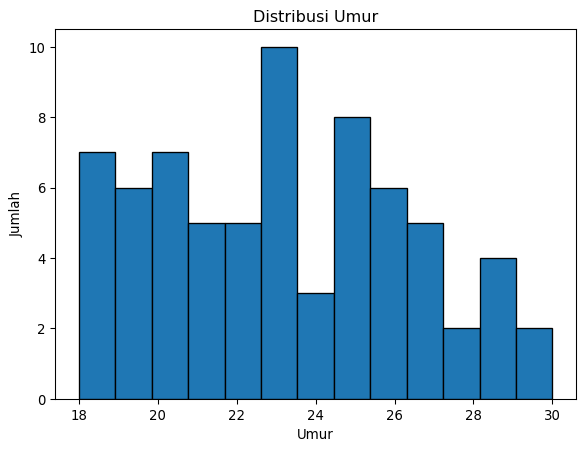

In [19]:
# bins adalah (max-min) dari umur
bins = int(max(data_preprocessed['Umur']) - min(data_preprocessed['Umur'])+1)

# Membuat histogram
plt.hist(data_preprocessed['Umur'], bins=bins, edgecolor='black')
plt.xlabel('Umur')
plt.ylabel('Jumlah')
plt.title('Distribusi Umur')
plt.show()

## 7.2 Jumlah Mahasiswa per Program Studi (column chart)

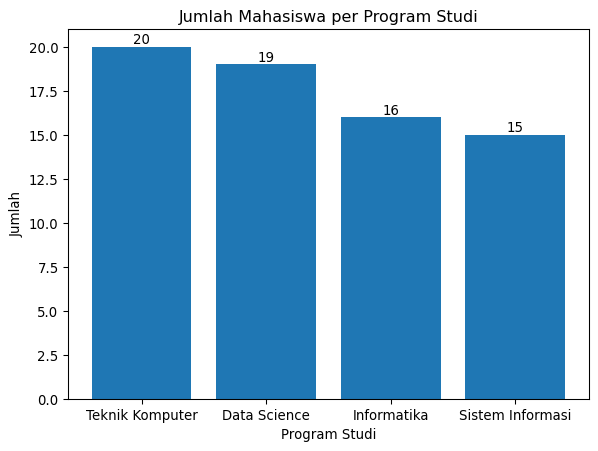

In [20]:
# Membuat column chart
plt.bar(data_preprocessed['Prodi'].unique(), data_preprocessed['Prodi'].value_counts())
plt.xlabel('Program Studi')
plt.ylabel('Jumlah')
plt.title('Jumlah Mahasiswa per Program Studi')

# tambah label angka di atas bar
for i, v in enumerate(data_preprocessed['Prodi'].value_counts()):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

# 8. Kesimpulan

# 9. Lampiran

## 9.1 Diagnostik Python

In [21]:
import IPython as ipy
print(ipy.sys_info())

{'commit_hash': 'f5e51b8',
 'commit_source': 'installation',
 'default_encoding': 'utf-8',
 'ipython_path': '/var/home/nord/ContainerHomes/ubuntu-bigdata/miniconda3/envs/machine-learning-tugas/lib/python3.14/site-packages/IPython',
 'ipython_version': '9.11.0',
 'os_name': 'posix',
 'platform': 'Linux-6.17.7-ba25.fc43.x86_64-x86_64-with-glibc2.39',
 'sys_executable': '/var/home/nord/ContainerHomes/ubuntu-bigdata/miniconda3/envs/machine-learning-tugas/bin/python',
 'sys_platform': 'linux',
 'sys_version': '3.14.4 | packaged by Anaconda, Inc. | (main, Apr 14 2026, '
                '17:07:44) [GCC 14.3.0]'}